In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv('cleaned_dataset.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,availability_365
0,1.059975e+18,"Blueground | Lower Queen Anne, garden & game room",107434423.0,Blueground,Queen Anne,Lower Queen Anne,47.625613,-122.357086,Entire home/apt,103.0,31.0,0.0,01-Jan-25,169.0
1,1.289101e+18,Blueground | First Hill 1bd apartment,107434423.0,Blueground,Central Area,Atlantic,47.596828,-122.312028,Entire home/apt,148.0,31.0,0.0,01-Jan-25,350.0
2,1.258584e+18,"Blueground | U Distric, gym, bbq, w/d & rooftop",107434423.0,Blueground,Other neighborhoods,Ravenna,47.662697,-122.294739,Entire home/apt,151.0,31.0,0.0,01-Jan-25,323.0
3,1.029558e+18,"Blueground | Bell Town, rooftop, nr dining & s...",107434423.0,Blueground,Downtown,Belltown,47.614846,-122.352223,Entire home/apt,130.0,31.0,0.0,01-Jan-25,333.0
4,1.295664e+18,"Blueground | First Hill, rooftop, nr stadiums",107434423.0,Blueground,Central Area,Atlantic,47.596828,-122.312028,Entire home/apt,149.0,31.0,0.0,01-Jan-25,290.0


In [6]:
df = df[['neighbourhood', 'room_type', 'price', 'minimum_nights',
         'number_of_reviews', 'availability_365']]

In [7]:
df = df[(df['price'] > 0) & (df['price'] < 1000)]
df = df[(df['minimum_nights'] < 365)]

In [8]:
X = df.drop('price', axis=1)
y = df['price']

In [9]:
cat_cols = ['neighbourhood', 'room_type']
num_cols = ['minimum_nights', 'number_of_reviews', 'availability_365']

In [15]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

In [16]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
y_pred = model.predict(X_test)

d:\Apps\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [20]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MAE: 63.72860030195244
RMSE: 94.02376887756496
R² Score: 0.024350828605820385


LINEAR REGRESSION (ACTUAL PRICE VS PREDICTED PRICE)

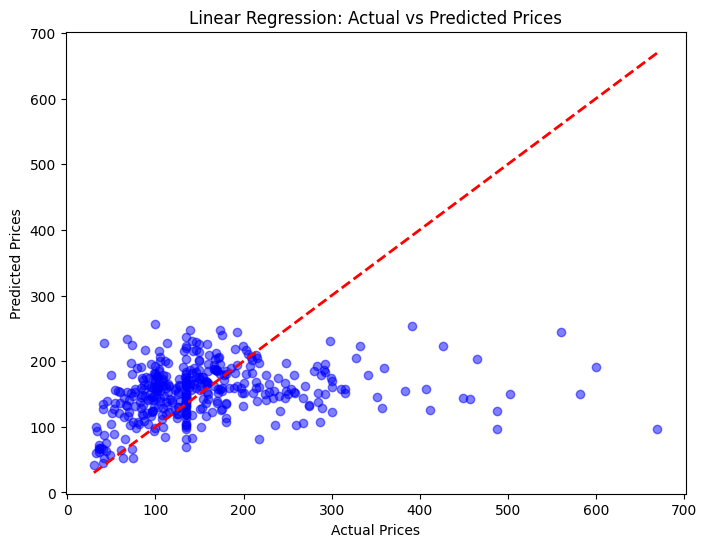

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color="red", linestyle="--", linewidth=2)  # Perfect fit line
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.show()


RESIDUAL PLOT

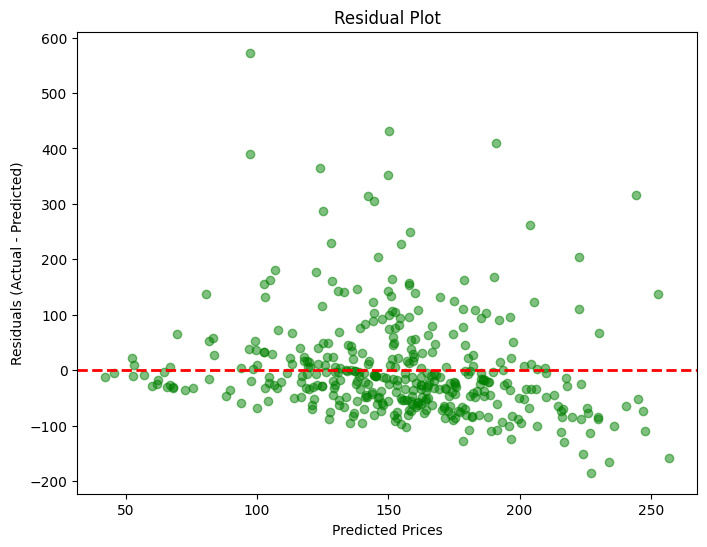

In [23]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5, color="green")
plt.axhline(y=0, color="red", linestyle="--", linewidth=2)
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()
